In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.animation as animation
import pandas as pd

In [100]:
def animated_plot(x1, x2, fx):
    '''
    ***Non important pour le devoir!***
    Fonction pour les une animation de la trajectoire d'optimisation.
    '''
    fig, ax = plt.subplots(figsize=(8,6))

    ax.scatter(x1, x2, c=fx, cmap="viridis", edgecolor="k")
    line, = ax.plot([], [], 'r-')
    points = ax.scatter([], [], s=0.1)
    def update(i):
        line.set_data(x1[:i], x2[:i])
        points.set_offsets(np.c_[x1[:i], x2[:i]])
        return line, points
    ani = animation.FuncAnimation(fig, update, frames=len(x1), interval=50)


def data_extracter(algo_num, instance,max_index=0,method=""):
    '''
    Return x1, x2, fx in a numpy array
    '''
    path = f"Ch4/1/Algo_{algo_num}/{instance}/history.0.txt"
    
    if method == "simple":
        data = pd.read_csv(path, sep=r"\s+",header=None).to_numpy()
        return data[:, -1]
    
    data = np.loadtxt(path)
    if len(data[0])==4:
        return data[:, :-1][:,0], data[:, :-1][:,1], data[:, :-1][:,2], data[:, -1]
    if len(data[0])!=3:
        print(f"ERROR THE DIMENSION DOES NOT WORK, PLEASE CHECK THE DIMENSION OF x.")
    if max_index != 0:
        return data[:max_index, :-1][:,0], data[:max_index, :-1][:,1], data[:max_index, -1]
    
    return data[:, :-1][:,0], data[:, :-1][:,1], data[:, -1]

def Trajectory_plot(x1, x2, fx):
    plt.scatter(x1, x2, c=fx, cmap="viridis", edgecolor="k")
    plt.plot(x1, x2)
    return

def Convergence_plot(x, fx):
    fbest = np.array([fx[0]])
    xbest = np.array([x[:,0]])
    iter_num_fbest = np.array([1])
    f0 = fx[0]
    for index, value in enumerate(fx):
        if value < f0:
            fbest = np.append(fbest, value)
            xbest = np.vstack((xbest, x[:,index]))
            iter_num_fbest = np.append(iter_num_fbest, index+1)
            f0 = value
    return iter_num_fbest, fbest, xbest

a)

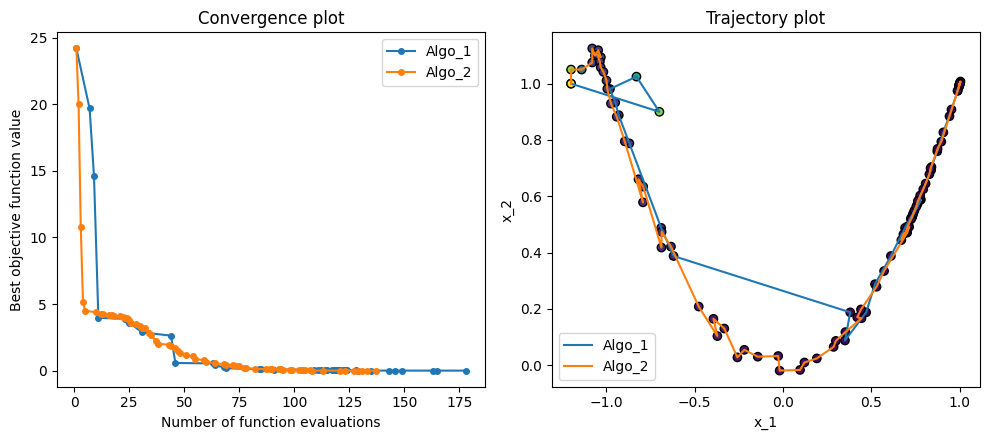

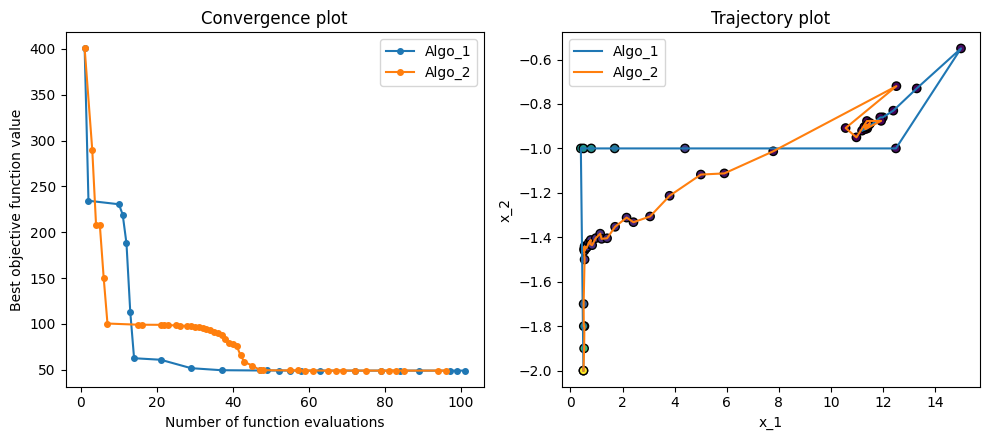

In [101]:
for inst in [19,37]:
    fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(10,4.5))

    instance = inst

    for algo in [1,2]:
        x1, x2, fx = data_extracter(algo, instance)
        x = np.array([x1,x2])
        # print(x[:,0])
        iter_num_fbest, fbest, xbest = Convergence_plot(x,fx)
        ax1.scatter(xbest[:,0], xbest[:,1], c=fbest, cmap="viridis", edgecolor="k")
        ax1.plot(xbest[:,0], xbest[:,1], label=f'Algo_{algo}')
        ax1.set_xlabel('x_1')
        ax1.set_ylabel('x_2')
        ax1.set_title('Trajectory plot')
        ax1.legend()
        
        ax2.plot(iter_num_fbest, fbest, '.-', markersize=8, label=f'Algo_{algo}')
        ax2.set_xlabel('Number of function evaluations')
        ax2.set_ylabel('Best objective function value')
        ax2.set_title('Convergence plot')
        ax2.legend()


    plt.tight_layout()
    plt.show()

b)

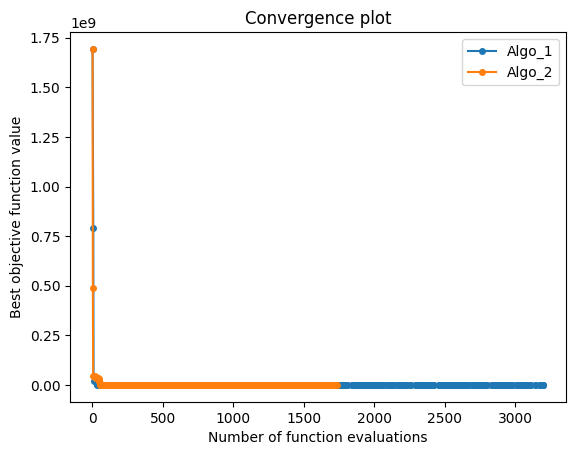

In [102]:
plt.figure()
for algo in [1,2]:
    x1, x2, x3, fx = data_extracter(algo,52)
    iter_num_fbest, fbest, xbest = Convergence_plot(np.array([x1,x2,x3]),fx)
    plt.plot(iter_num_fbest, fbest, '.-', markersize=8, label=f'Algo_{algo}')


plt.xlabel('Number of function evaluations')
plt.ylabel('Best objective function value')
plt.title('Convergence plot')
plt.legend()
plt.show()

c)

In [ ]:
def facc(f_val, f0, fbest):
    return (f_val-f0) / (fbest - f0)

def analysis(tau,algo, instance):
    fbest = 1e6
    # finding fbest
    for ind_a, a in enumerate(algo):
        for ind_p, p in enumerate(instance):
            fx = data_extracter(a, p, method="simple")
            if np.min(fx) < fbest:
                if np.min(fx) == None:
                    continue
                else:
                    fbest = np.min(fx)

    Nap = np.zeros((len(algo), len(instance)))
    for ind_a, a in enumerate(algo):
        for ind_p, p in enumerate(instance):
            # Findind N
            fx = data_extracter(a, p, method="simple")
            facc = (fx-fx[0]) / (fbest - fx[0])
            Nap[ind_a, ind_p] = np.argmax(facc >= 1-tau)

    Tap = np.where(Nap != 0, 1, 0)
    Nap_min = np.min(np.where(Tap==1, Nap, np.inf))
    rap = np.where(Tap == 1, Nap/Nap_min, np.inf)

    return Nap, Tap, rap

def performance_profile(tau, algo, instance, alpha_ratio=np.arange(1, 30, 1)):
    rap = analysis(tau, algo, instance)[2]
    
    rho = np.zeros((len(algo), len(alpha_ratio)))

    for ind_algo in range(len(algo)):
        for i_a, a in enumerate(alpha_ratio**2):
            rho[ind_algo, i_a] = np.sum(np.where(rap[ind_algo]<=a, 1, 0)) / len(instance)
    
    return rho
    
def data_dim(algo, instance):
    n_p = np.zeros((len(algo), len(instance)))
    for ind_a, a in enumerate(algo):
        for ind_i, i in enumerate(instance):
            with open(f"Ch4/1/Algo_{a}/{i}/history.0.txt", "r") as f:
                n_p[ind_a, ind_i] = len(np.fromstring(f.readline(), sep=" ")[:-1])
    return n_p


def data_profile(tau, algo, instance, k_groupe=np.linspace(0, 25, 100)):
    Nap, Tap = analysis(tau, algo, instance)[:-1]
    n_p = data_dim(algo, instance)

    da = np.zeros((len(algo), len(k_groupe)))

    for ind_algo in range(len(algo)):
        for i_k, k in enumerate(k_groupe):
            da[ind_algo, i_k] = np.sum(np.where((Nap[ind_algo] <= (n_p[ind_algo]+1)*k*Tap[ind_algo]) & (Tap[ind_algo]==1), 1, 0)) / len(instance)

    return da

In [ ]:
tau = [0.05, 0.01]
algo = [1,2]
instance = np.arange(1,160,1)


[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159]


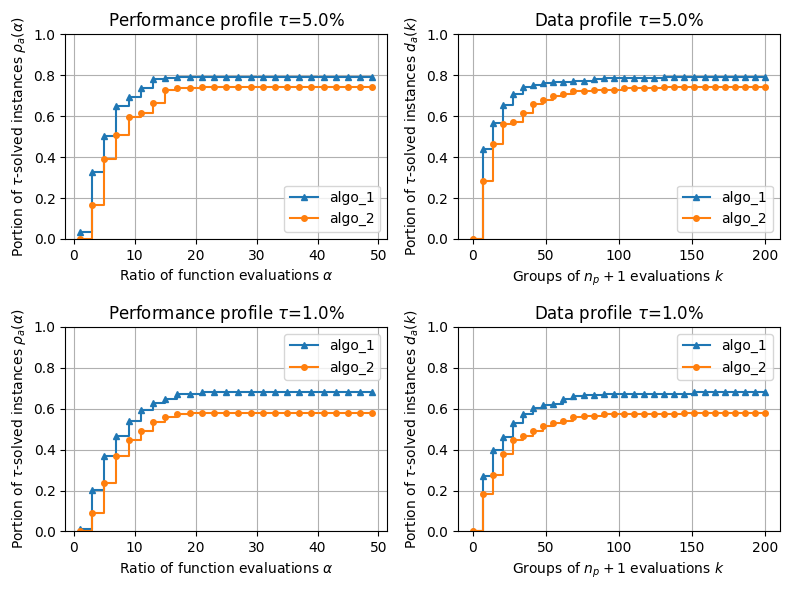

In [105]:

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
rho_label = r"$\rho_a(\alpha)$"
tau_label = r"$\tau$"
alpha_label = r"$\alpha$"

alpha_ratio = np.arange(1, 50, 2)
ax[0, 0].set_title(f"Performance profile {tau_label}={tau[0]*100}%")
rho = performance_profile(tau[0],algo, instance, alpha_ratio)
ax[0,0].step(alpha_ratio, rho[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[0,0].step(alpha_ratio, rho[1,:], label='algo_2', marker='o', where='post', ms=4)
ax[0,0].set_ylim(0,1)
ax[0,0].legend()
ax[0,0].set_xlabel(f"Ratio of function evaluations {alpha_label}")
ax[0,0].set_ylabel(f"Portion of {tau_label}-solved instances {rho_label}")
ax[0,0].grid()

ax[1, 0].set_title(f"Performance profile {tau_label}={tau[1]*100}%")
rho = performance_profile(tau[1],algo, instance, alpha_ratio)
ax[1,0].step(alpha_ratio, rho[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[1,0].step(alpha_ratio, rho[1,:], label='algo_2', marker='o', where='post', ms=4)
ax[1,0].set_ylim(0,1)
ax[1,0].legend()
ax[1,0].set_xlabel(f"Ratio of function evaluations {alpha_label}")
ax[1,0].set_ylabel(f"Portion of {tau_label}-solved instances {rho_label}")
ax[1,0].grid()

k_groupe = np.linspace(0, 200, 30)
ax[0, 1].set_title(f"Data profile {tau_label}={tau[0]*100}%")
da = data_profile(tau[0], algo, instance,k_groupe=k_groupe)
ax[0,1].step(k_groupe, da[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[0,1].step(k_groupe, da[1,:], label='algo_2', marker='o', where='post', ms=4)
ax[0,1].set_ylim(0,1)
ax[0,1].legend()
ax[0,1].set_xlabel(f"Groups of {r"$n_p+1$"} evaluations {r"$k$"}")
ax[0,1].set_ylabel(f"Portion of {tau_label}-solved instances {r"$d_a(k)$"}")
ax[0,1].grid()

ax[1, 1].set_title(f"Data profile {tau_label}={tau[1]*100}%")
da = data_profile(tau[1], algo, instance,k_groupe=k_groupe)
ax[1,1].step(k_groupe, da[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[1,1].step(k_groupe, da[1,:], label='algo_2', marker='o', where='post', ms=4)
ax[1,1].set_ylim(0,1)
ax[1,1].legend()
ax[1,1].set_xlabel(f"Groups of {r"$n_p+1$"} evaluations {r"$k$"}")
ax[1,1].set_ylabel(f"Portion of {tau_label}-solved instances {r"$d_a(k)$"}")
ax[1,1].grid()


plt.tight_layout()
plt.show()

f)

In [ ]:
instance_algo_1 = np.arange(1,160,1)
instance_algo_2 = np.arange(1,160,1)

crashed_site_1 = [17, 31, 32, 33]
crashed_site_2 = [14, 17, 28]

for c in range(len(crashed_site_1)):
    instance_algo_1 = instance_algo_1[instance_algo_1 != crashed_site_1[c]]

for c in range(len(crashed_site_2)):
    instance_algo_2 = instance_algo_2[instance_algo_2 != crashed_site_2[c]]

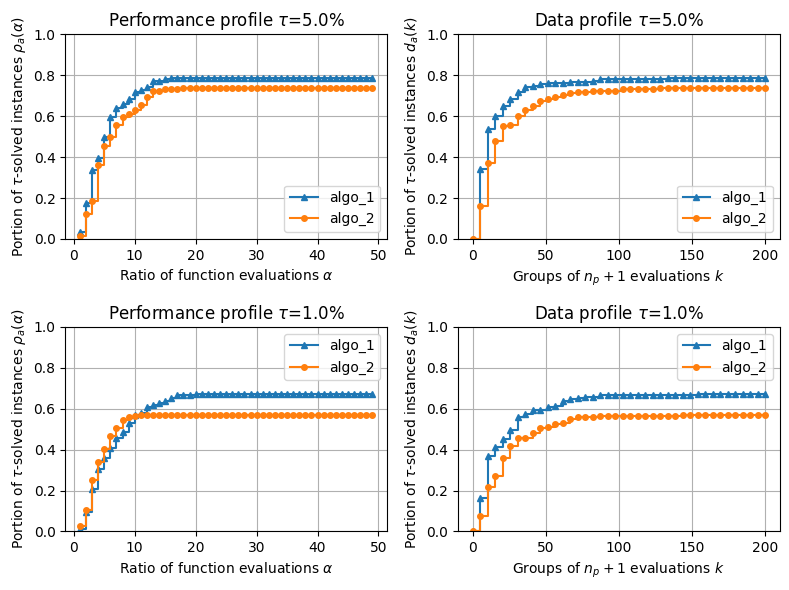

In [119]:
fig, ax = plt.subplots(2, 2, figsize=(8, 6))
rho_label = r"$\rho_a(\alpha)$"
tau_label = r"$\tau$"
alpha_label = r"$\alpha$"

alpha_ratio = np.arange(1, 50, 1)
ax[0, 0].set_title(f"Performance profile {tau_label}={tau[0]*100}%")
rho_A1 = performance_profile(tau[0], algo[:1], instance_algo_1, alpha_ratio)
rho_A2 = performance_profile(tau[0], algo[1:], instance_algo_2, alpha_ratio)

ax[0,0].step(alpha_ratio, rho_A1[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[0,0].step(alpha_ratio, rho_A2[0,:], label='algo_2', marker='o', where='post', ms=4)
ax[0,0].set_ylim(0,1)
ax[0,0].legend()
ax[0,0].set_xlabel(f"Ratio of function evaluations {alpha_label}")
ax[0,0].set_ylabel(f"Portion of {tau_label}-solved instances {rho_label}")
ax[0,0].grid()

ax[1, 0].set_title(f"Performance profile {tau_label}={tau[1]*100}%")
rho_A1 = performance_profile(tau[1], algo[:1], instance_algo_1, alpha_ratio)
rho_A2 = performance_profile(tau[1], algo[1:], instance_algo_2, alpha_ratio)

ax[1,0].step(alpha_ratio, rho_A1[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[1,0].step(alpha_ratio, rho_A2[0,:], label='algo_2', marker='o', where='post', ms=4)
ax[1,0].set_ylim(0,1)
ax[1,0].legend()
ax[1,0].set_xlabel(f"Ratio of function evaluations {alpha_label}")
ax[1,0].set_ylabel(f"Portion of {tau_label}-solved instances {rho_label}")
ax[1,0].grid()

k_groupe = np.linspace(0, 200, 40)
ax[0, 1].set_title(f"Data profile {tau_label}={tau[0]*100}%")
da_A1 = data_profile(tau[0], algo[:1], instance_algo_1,k_groupe=k_groupe)
da_A2 = data_profile(tau[0], algo[1:], instance_algo_2,k_groupe=k_groupe)
ax[0,1].step(k_groupe, da_A1[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[0,1].step(k_groupe, da_A2[0,:], label='algo_2', marker='o', where='post', ms=4)
ax[0,1].set_ylim(0,1)
ax[0,1].legend()
ax[0,1].set_xlabel(f"Groups of {r"$n_p+1$"} evaluations {r"$k$"}")
ax[0,1].set_ylabel(f"Portion of {tau_label}-solved instances {r"$d_a(k)$"}")
ax[0,1].grid()

ax[1, 1].set_title(f"Data profile {tau_label}={tau[1]*100}%")
da_A1 = data_profile(tau[1], algo[:1], instance_algo_1,k_groupe=k_groupe)
da_A2 = data_profile(tau[1], algo[1:], instance_algo_2,k_groupe=k_groupe)
ax[1,1].step(k_groupe, da_A1[0,:], label='algo_1', marker='^', where='post', ms=4)
ax[1,1].step(k_groupe, da_A2[0,:], label='algo_2', marker='o', where='post', ms=4)
ax[1,1].set_ylim(0,1)
ax[1,1].legend()
ax[1,1].set_xlabel(f"Groups of {r"$n_p+1$"} evaluations {r"$k$"}")
ax[1,1].set_ylabel(f"Portion of {tau_label}-solved instances {r"$d_a(k)$"}")
ax[1,1].grid()


plt.tight_layout()
plt.show()